In [1]:
import vtk
from vtk import vtkXMLUnstructuredGridReader
from vtk.util.numpy_support import vtk_to_numpy
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy.spatial import KDTree
import pygmt
import pandas as pd

def cartesian_to_spherical(x, y, z):
    """
    Takes an x, y, z and converts it to spherical coordinates. Returns r, theta, phi
    """
    r = np.sqrt(x**2 + y**2 + z**2)
    theta = 90 - np.rad2deg( np.arccos( z / (np.sqrt(x**2 + y**2 + z**2)) ) )
    phi =  np.sign(y) * np.rad2deg(np.arccos( x / np.sqrt(x**2 + y**2) ))
    phi[np.where(phi < 0)] = phi[np.where(phi < 0)] + 360
    phi[np.where(phi == 0)] = 180
    
    return r, phi, theta

def spherical_to_global_cartesian(r, phi, theta):
    """
    Takes spherical coordinates r, theta, and phi and converts to Cartesian coordinates.
    Returns x, y, z
    """
    x = r * np.sin(np.deg2rad(90 - theta)) * np.cos(np.deg2rad(phi))
    y = r * np.sin(np.deg2rad(90 - theta)) * np.sin(np.deg2rad(phi))
    z = r * np.cos(np.deg2rad(90 - theta))
    
    return x, y, z

In [19]:
# Load the ASCII file (assuming space-separated values)
coast_geo = np.loadtxt("coastline.txt")
r = 6240e3 * np.ones(len(data[:, 0]))

coast_geo[:, 0], coast_geo[:, 1], coast_geo[:, 2] = spherical_to_global_cartesian(r, coast_geo[:, 0], coast_geo[:, 1])

# Convert to Pandas DataFrame
df = pd.DataFrame(coast_geo, columns=["X", "Y", "Z"])

# Save as CSV (comma-separated, with header)
df.to_csv("under_LAB_coastline.csv", index=False)

TypeError: 'vtkmodules.vtkCommonDataModel.vtkUnstructuredGrid' object is not subscriptable

In [29]:
# sol_dir_path = "../ASPECT_models/5e20_10kmweak_dry/solution/"
# sol_dir_path = "/Users/danieldouglas/FINAL_SLABS/plate_model/dry/5e20_10kmweak_dry/solution/"
sol_dir_path = "/Users/danieldouglas/FINAL_SLABS/plate_model/NOSTOKES_hydration_test/solution/"

solutions = np.sort(os.listdir( sol_dir_path ))

t_step = 0
pos_solution = np.empty(0)
litho_total = np.empty(0)
crust_total = np.empty(0)
heat_flux_raw_total = np.empty(0)
TVZ_total = np.empty(0)
interface_total = np.empty(0)
overriding_total = np.empty(0)

for soln in solutions:
    if soln[-4:-1] == '.vt' and soln[9:14] == str(t_step).zfill(5):
        
        file_path = os.path.join(sol_dir_path, soln)
        reader = vtkXMLUnstructuredGridReader()
        reader.SetFileName(file_path)
        reader.Update()
        data = reader.GetOutput()
        points = data.GetPoints()
        x = vtk_to_numpy(points.GetData())
        litho = vtk_to_numpy(data.GetPointData().GetArray('Base_Subducting'))
        overriding = vtk_to_numpy(data.GetPointData().GetArray('Base_Continent'))
        crust = vtk_to_numpy(data.GetPointData().GetArray('Crust'))
        TVZ = vtk_to_numpy(data.GetPointData().GetArray('TVZ'))
        heat_flux = vtk_to_numpy(data.GetPointData().GetArray('heat_flux_map'))

        if len(pos_solution) == 0 :
            pos_solution = x
        else:
            pos_solution = np.concatenate( (pos_solution, x) )
        litho_total = np.concatenate( (litho_total, litho) )
        overriding_total = np.concatenate( (overriding_total, overriding) )
        TVZ_total = np.concatenate( (TVZ_total, TVZ) )
        heat_flux_raw_total = np.concatenate( (heat_flux_raw_total, heat_flux) )
        crust_total = np.concatenate( (crust_total, crust) )

In [30]:
ASP_r, ASP_phi, ASP_theta = cartesian_to_spherical(pos_solution[:, 0], pos_solution[:, 1], pos_solution[:, 2])
R_bounds = np.array([6365e3, 6375e3])
shallow_indices = np.where( (ASP_r <= np.max(R_bounds)) & (ASP_r >= np.min(R_bounds)) )

shallow_r, shallow_phi, shallow_theta = ASP_r[shallow_indices], ASP_phi[shallow_indices], ASP_theta[shallow_indices]

shallow_x, shallow_y, shallow_z = spherical_to_global_cartesian(shallow_r, shallow_phi, shallow_theta)

shallow_heat_flux = heat_flux_raw_total[shallow_indices]

shallow_KDTree = KDTree(np.c_[shallow_x, shallow_y, shallow_z])

In [31]:
heat_flux_data_points = np.array([
[46.06060606060606, 47.33009708737863],
[49.93939393939395, 42.23300970873785],
[58.18181818181818, 46.60194174757282],
[61.09090909090909, 42.23300970873787],
[63.03030303030303, 37.864077669902905],
[63.51515151515153, 46.60194174757281],
[75.15151515151516, 37.86407766990292],
[76.60606060606061, 40.77669902912622],
[82.90909090909093, 48.7864077669903],
[97.93939393939395, 46.60194174757282],
[97.45454545454548, 41.50485436893204],
[99.87878787878789, 35.67961165048544],
[105.6969696969697, 27.669902912621378],
[128.00000000000003, 38.592233009708735],
[157.57575757575762, 59.70873786407769],
[169.69696969696975, 105.58252427184468],
[173.5757575757576, 52.42718446601938],
[187.63636363636365, 29.126213592232986],
[191.0303030303031, 24.757281553398034],
[199.2727272727273, 42.23300970873787],
[203.1515151515152, 50.24271844660191],
[271.03030303030306, 42.233009708737875],
[278.3030303030304, 29.126213592232986],
[304.4848484848485, 0.7281553398057867],
[321.9393939393939, 0.7281553398058178],
[334.54545454545456, 8.00970873786413],
[336.96969696969705, 12.378640776699058],
[342.78787878787887, 5.2130359358230805e-30],
[352.48484848484856, 0.7281553398058604],
[367.51515151515156, 53.88349514563112],
[396.1212121212122, 63.349514563106794]])

In [38]:
len(heat_flux_lon)

61

In [42]:
heat_flux_lat = np.array([39.88, 39.91, 40.11, 40.13, 40.24, 40.26,
                          40.27, 40.29, 40.37, 40.41, 39.53, 40.52,
                          40.56, 41.82, 41.69, 41.52, 41.53, 41.53,
                          41.54, 41.55, 41.56, 41.49, 41.49, 41.43,
                          39.02, 42.48, 42.46, 42.24, 42.20, 42.18,
                          42.16, 42.11, 42.08, 42.06, 42.04, 42.02,
                          42.00, 38.98, 39.45, 39.85, 41.52, 41.54,
                          42.35, 41.89, 41.88, 41.87, 41.86, 41.85,
                          41.84, 41.83, 41.82, 41.80, 40.93, 40.89,
                          40.89, 40.87, 40.86, 40.86, 40.83, 40.83]) * -1

heat_flux_lon = np.array([177.80, 177.81, 177.89, 177.90, 177.95, 177.96,
                          177.97, 177.98, 178.02, 178.03, 177.76, 178.03,
                          178.03, 175.73, 175.71, 176.10, 176.17, 176.25,
                          176.32, 176.39, 176.50, 175.76, 176.61, 176.56,
                          178.78, 174.85, 174.83, 174.81, 174.78, 174.76,
                          174.74, 174.71, 174.68, 174.67, 174.67, 174.63,
                          174.63, 178.71, 178.54, 178.41, 176.06, 176.32,
                          174.91, 175.20, 175.29, 175.39, 175.49, 175.59,
                          175.69, 175.79, 175.89, 175.98, 177.80, 177.50,
                          177.49, 177.40, 177.37, 177.35, 177.26, 177.26])

heat_flux_val = np.array([33, 34, 33, 32, 39, 34, 35, 37, 37, 40, 33, 36,
                          36, 38, 30, 27, 55, 35, 33, 39, 33, 16, 34, 35,
                          40, 32, 36, 43, 43, 40, 43, 32, 23, 39, 33, 30,
                          42, 52, 46, 42, 40, 42, 43, 34, 41, 42, 41, 37,
                          54, 32, 41, 35, 36, 49, 49])

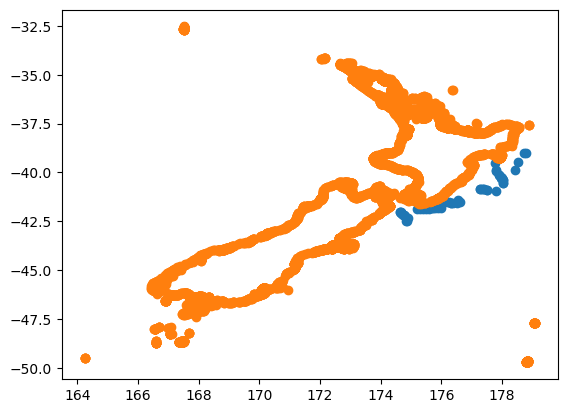

In [43]:
COAST = np.loadtxt("coastline.txt")
plt.scatter(heat_flux_lon, heat_flux_lat)
plt.scatter(COAST[:, 0], COAST[:, 1])

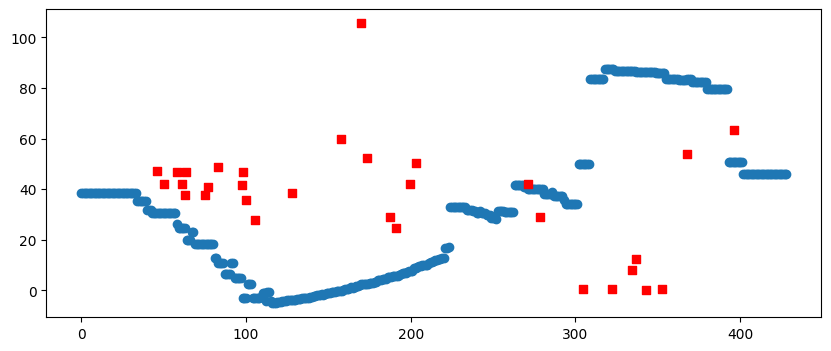

In [33]:
lon_lat_slice = np.array([[179.25, -40.0], \
                          [175.50, -37.5]])

profile = pygmt.project(center=[lon_lat_slice[0][0], lon_lat_slice[0][1]], endpoint=[lon_lat_slice[1][0], lon_lat_slice[1][1]], generate=1e3/1e3, unit=True).to_numpy()
prof_lon = profile[:, 0]
prof_lat = profile[:, 1]
prof_dist = profile[:, 2]
prof_r = np.ones(len(profile[:, 0])) * 6371e3
prof_lon[np.where(prof_lon < 0)] = prof_lon[np.where(prof_lon < 0)] + 360
prof_lon[np.where(prof_lon == 0)] = 180

prof_x, prof_y, prof_z = spherical_to_global_cartesian(prof_r, prof_lon, prof_lat)

prof_heat_flux = np.zeros(len(prof_x))
for i in range(len(prof_x)):
    dd, index_of_profile = shallow_KDTree.query([prof_x[i], prof_y[i], prof_z[i]], k=1)
    prof_heat_flux[i] = shallow_heat_flux[index_of_profile] * 1000

plt.figure(dpi=100, figsize=(10, 4))
plt.scatter(prof_dist, prof_heat_flux)
plt.scatter(heat_flux_data_points[:, 0], heat_flux_data_points[:, 1], c='r', marker='s')

gmtset [ERROR]: Pen name None not recognized!
gmtset [WARNING]: Representation of pen width (None) not recognized. Using default.


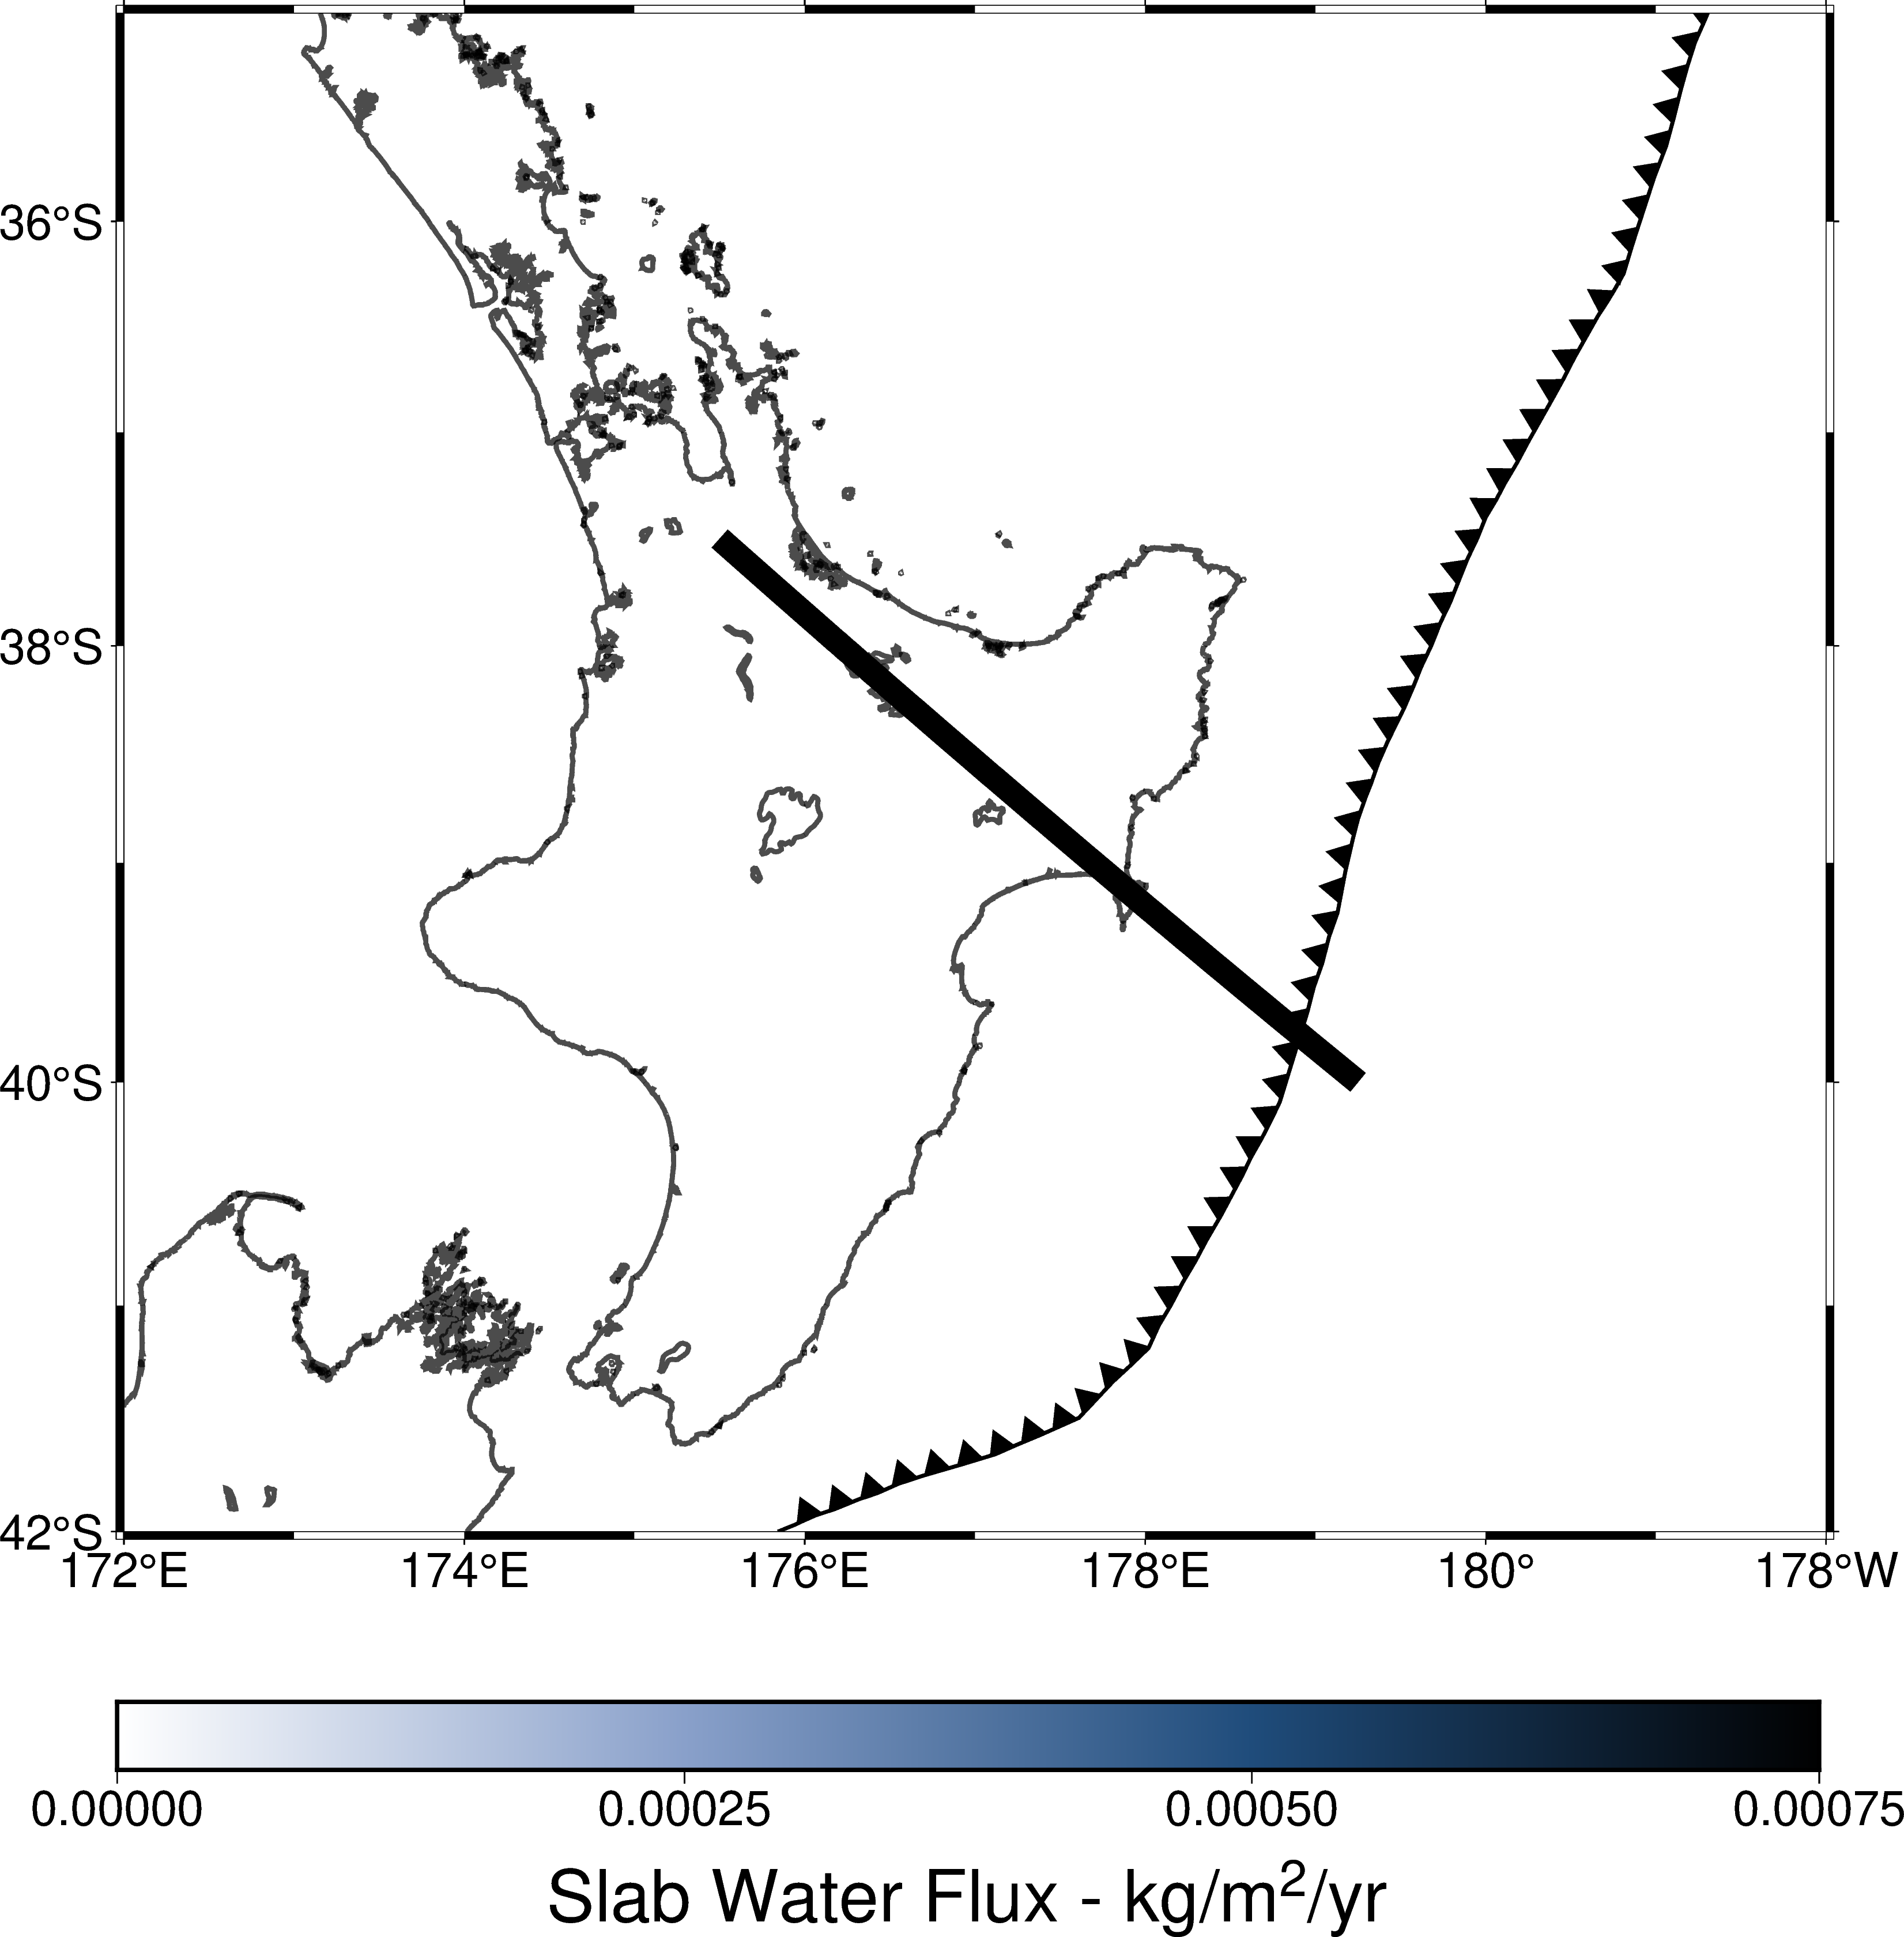

In [34]:
trench = np.loadtxt(fname="trench_contour.csv", delimiter=',')[0:270]
plot_region = [172, 182, -42, -35]

fig = pygmt.Figure()
pygmt.config(FONT_LABEL='30p', MAP_LABEL_OFFSET='0.5', MAP_TICK_PEN_PRIMARY=None, FONT_ANNOT_PRIMARY='20p')
fig.basemap(region=plot_region, projection="M25c", frame=["af"])#, "+tGeologic Harzard Map"])
pygmt.makecpt(cmap="oslo", series=[0, 0.00075, 0.00025], continuous=True, reverse=True)

fig.colorbar(position="JBC+o-0.1c/2.5c+w25c/1c+h", frame=["0.00025", "x+lSlab Water Flux - kg/m@+2@+/yr"])

fig.coast(
    shorelines="2p,black",
    transparency=30
)
fig.plot(x=trench[:, 0], y=trench[:, 1], pen="1.5p", style="f0.5c/0.4c+l+t+o0.5c+p", fill='black')
fig.plot(x=profile[:, 0], y=profile[:, 1], pen='10p,black')
fig.plot(x=profile[:, 0][0], y=profile[:, 1][0], style='t+600')
fig.show()